In [82]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,country,clinical_index
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-3.920000
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,1,Hungary,-0.670000
2,29.0,1.0,2.0,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-1.947393
3,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary,-1.160000
4,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-0.690000


In [83]:
df.shape

(920, 16)

In [84]:
df_clean = df.copy()

In [85]:
df_clean.loc[df_clean["chol"] == 0, "chol"] = np.nan

In [86]:
df_clean.loc[df_clean["trestbps"] == 0, "trestbps"] = np.nan

Data cleaning started by converting clinically impossible values into missing values.

- Cholesterol values equal to 0 were treated as missing because a cholesterol level of zero is physiologically implausible.
- Resting blood pressure values equal to 0 were also treated as missing for the same reason.

These values were converted to NaN to ensure that subsequent imputation methods treat them as missing observations rather than valid measurements.

In [87]:
df_clean.isna().sum()

age                 0
sex                 0
cp                  0
trestbps           60
chol              202
fbs                90
restecg             2
thalach            55
exang              55
oldpeak            62
slope             309
ca                611
thal              486
target              0
country             0
clinical_index     55
dtype: int64

In [88]:
missing_pct = (df_clean.isna().sum() / len(df_clean) * 100).sort_values(ascending=False)
missing_pct

ca                66.413043
thal              52.826087
slope             33.586957
chol              21.956522
fbs                9.782609
oldpeak            6.739130
trestbps           6.521739
thalach            5.978261
exang              5.978261
clinical_index     5.978261
restecg            0.217391
cp                 0.000000
sex                0.000000
age                0.000000
target             0.000000
country            0.000000
dtype: float64

Since only two observations (0.22%) contain missing values in restecg, these rows were removed from the dataset. The impact on sample size and class distribution is negligible.

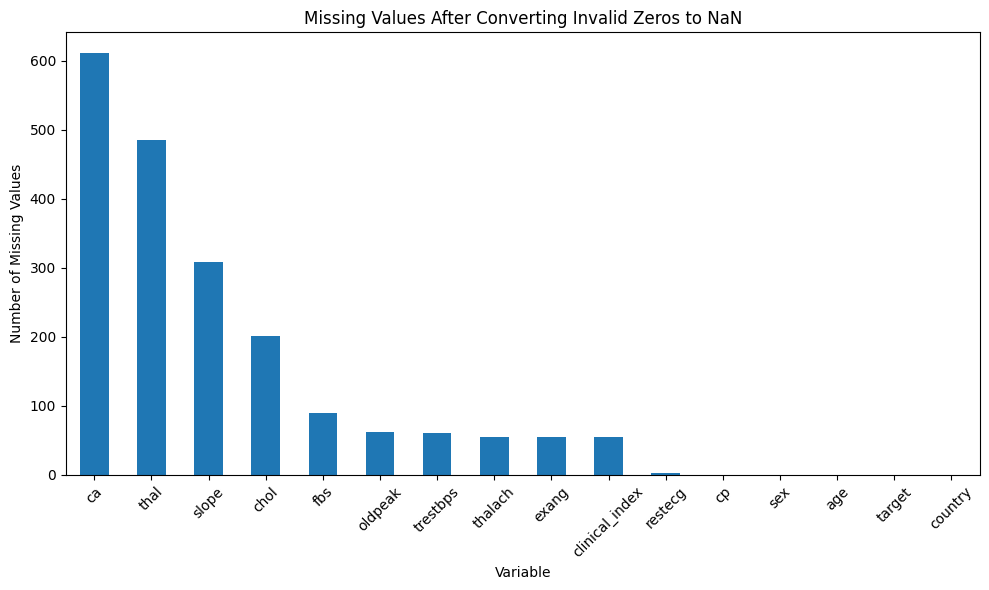

In [89]:
missing_counts = df_clean.isna().sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing_counts.plot(kind="bar")

plt.title("Missing Values After Converting Invalid Zeros to NaN")
plt.xlabel("Variable")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [90]:
df_clean = df_clean.dropna(subset= ["restecg"])

df_clean.shape

(918, 16)

In [91]:
df_clean["exang"].value_counts(dropna=False)

exang
0.0    526
1.0    337
NaN     55
Name: count, dtype: int64

In [92]:
df_clean["exang"] = df_clean["exang"].fillna(
    df_clean["exang"].mode()[0]
)

In [93]:
df_clean["exang"].value_counts(dropna=False)

exang
0.0    581
1.0    337
Name: count, dtype: int64

In [94]:
df_clean["fbs"].value_counts(dropna=False)

fbs
0.0    691
1.0    138
NaN     89
Name: count, dtype: int64

In [95]:
df_clean["fbs"] = df_clean["fbs"].fillna(
    df_clean["fbs"].mode()[0]
)

In [96]:
df_clean["fbs"].value_counts(dropna=False)

fbs
0.0    780
1.0    138
Name: count, dtype: int64

In [97]:
df_clean["thalach"].describe()

count    863.000000
mean     137.528389
std       25.950226
min       60.000000
25%      120.000000
50%      140.000000
75%      157.000000
max      202.000000
Name: thalach, dtype: float64

Since the mean (137.5) and median (140) are very similar, the distribution of thalach appears approximately symmetric. Therefore, mean imputation is considered acceptable for the missing values.

In [98]:
df_clean["thalach"] = df_clean["thalach"].fillna(
    df_clean["thalach"].mean()
)

In [99]:
df_clean["thalach"].describe()

count    918.000000
mean     137.528389
std       25.159969
min       60.000000
25%      120.000000
50%      138.000000
75%      156.000000
max      202.000000
Name: thalach, dtype: float64

In [100]:
df_clean["trestbps"].describe()

count    858.000000
mean     132.297203
std       18.546520
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

In [101]:
df_clean["trestbps"] = df_clean["trestbps"].fillna(
    df_clean["trestbps"].mean()
)

In [102]:
df_clean["trestbps"].describe()

count    918.000000
mean     132.297203
std       17.929500
min       80.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

In [103]:
df_clean["oldpeak"].describe()

count    856.000000
mean       0.880607
std        1.091840
min       -2.600000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64

The distribution of oldpeak appears moderately skewed, with a noticeable difference between the mean (0.88) and median (0.50). Therefore, median imputation was preferred to reduce the influence of extreme values.

In [104]:
df_clean["oldpeak"] = df_clean["oldpeak"].fillna(
    df_clean["oldpeak"].median()
)

In [105]:
df_clean["oldpeak"].describe()

count    918.000000
mean       0.854902
std        1.058606
min       -2.600000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: oldpeak, dtype: float64

In [106]:
df_clean["clinical_index"].describe()

count    863.000000
mean       0.081460
std        2.225077
min       -6.020000
25%       -1.275000
50%        0.310000
75%        1.555000
max        8.680000
Name: clinical_index, dtype: float64

The clinical_index variable exhibits a wide range of values, including both large negative and positive observations. To reduce the influence of extreme values, missing observations were imputed using the median rather than the mean.

In [107]:
df_clean["clinical_index"] = df_clean["clinical_index"].fillna(
    df_clean["clinical_index"].median()
)

In [108]:
df_clean["clinical_index"].describe()

count    918.000000
mean       0.095153
std        2.158000
min       -6.020000
25%       -1.150000
50%        0.310000
75%        1.460000
max        8.680000
Name: clinical_index, dtype: float64

In [109]:
df_clean["chol"].describe()

count    717.00000
mean     246.76569
std       58.54021
min       85.00000
25%      210.00000
50%      239.00000
75%      276.00000
max      603.00000
Name: chol, dtype: float64

In [110]:
df_clean.groupby("country")["chol"].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Cleveland,303.0,246.693069,51.776918,126.0,211.0,241.0,275.00,564.0
Hungary,270.0,250.685185,67.729679,85.0,209.0,243.0,281.75,603.0
Switzerland,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
VA,144.0,239.569444,52.788753,100.0,208.0,228.0,271.25,458.0


Since all cholesterol measurements in Switzerland were missing after converting zero values to NaN, country-specific imputation was not possible. Therefore, missing cholesterol values were replaced using the overall median cholesterol level observed in the remaining regions.

In [111]:
region_medians = (
    df_clean.groupby("country")["chol"]
    .median()
)

region_medians

country
Cleveland      241.0
Hungary        243.0
Switzerland      NaN
VA             228.0
Name: chol, dtype: float64

In [112]:
chol_impute = region_medians.dropna().median()
df_clean["chol"] = df_clean["chol"].fillna(chol_impute)

In [113]:
df_clean["chol"].describe()

count    918.000000
mean     245.503268
std       51.783033
min       85.000000
25%      217.250000
50%      241.000000
75%      266.750000
max      603.000000
Name: chol, dtype: float64

All cholesterol values from Switzerland were missing after recoding invalid zero values. Since country-specific imputation was not possible, missing cholesterol values were replaced using the median cholesterol level across the remaining regions (241 mg/dL).

In [114]:
df_clean["slope"].value_counts(dropna=False)

slope
2.0    345
NaN    308
1.0    202
3.0     63
Name: count, dtype: int64

In [115]:
df_clean.groupby("country")["slope"].value_counts(dropna=False)

country      slope
Cleveland    1.0      142
             2.0      140
             3.0       21
Hungary      NaN      189
             2.0       91
             1.0       12
             3.0        1
Switzerland  2.0       61
             1.0       32
             NaN       17
             3.0       12
VA           NaN      102
             2.0       53
             3.0       29
             1.0       16
Name: count, dtype: int64

In [116]:
df_clean.groupby("country")["slope"].apply(lambda x : x.isna().sum())

country
Cleveland        0
Hungary        189
Switzerland     17
VA             102
Name: slope, dtype: int64

Slope contains 34% missing values and exhibits a moderate correlation with the target variable (~0.28). Since aggressive imputation may distort the original distribution, the variable is retained for later evaluation during model development.

In [117]:
df_clean["thal"].value_counts(dropna=False)

thal
NaN    484
3.0    196
7.0    192
6.0     46
Name: count, dtype: int64

Thal contains 53% missing values and is strongly associated with the target variable (corr ≈ 0.41). Due to the high proportion of missing values, no imputation strategy was applied at this stage. Alternative approaches will be evaluated during model development.

In [118]:
df_clean["ca"].value_counts(dropna=False)

ca
NaN    609
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64

In [119]:
df_clean.isna().sum().sort_values(ascending=False)

ca                609
thal              484
slope             308
age                 0
chol                0
sex                 0
cp                  0
trestbps            0
thalach             0
restecg             0
fbs                 0
oldpeak             0
exang               0
target              0
country             0
clinical_index      0
dtype: int64

## Cleaning Decisions

- Removed 2 rows with missing restecg values.
- Replaced impossible cholesterol values (0) with NaN.
- Replaced impossible resting blood pressure values (0) with NaN.
- Imputed:
  - exang, fbs → mode
  - thalach, trestbps → mean
  - oldpeak, clinical_index → median
  - chol → median cholesterol from non-Switzerland regions


## Final Dataset Status

After cleaning and imputation, missing values remain only in:
- slope
- thal
- ca

These variables were retained because they show meaningful associations with the target variable and will be evaluated during model development.

In [120]:
df_clean.to_csv("../data/heart_cleaned.csv", index= False)

In [121]:
pd.read_csv("../data/heart_cleaned.csv").shape

(918, 16)